In [13]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA Available: True
Device: Tesla T4


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install facenet-pytorch --no-deps

In [16]:
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import numpy as np

print("Success! facenet-pytorch imported.")
print("NumPy version:", np.__version__)
print("CUDA Available:", torch.cuda.is_available())

Success! facenet-pytorch imported.
NumPy version: 2.1.3
CUDA Available: True


In [17]:
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Face detector
mtcnn = MTCNN(image_size=160, margin=20, keep_all=False, device=device)

# Pre-trained face recognition model (VGGFace2 pe trained)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print("Models loaded successfully!")

Using device: cuda


  0%|          | 0.00/107M [00:00<?, ?B/s]

Models loaded successfully!


In [18]:
from google.colab import files
import os

os.makedirs("/content/known_faces", exist_ok=True)

print("Un logon ki photos upload karo jinhe pehchanna hai.")
print("Tip: File ka naam person ke naam se rakho, jaise 'Ali.jpg', 'Ahmed.jpg'")
uploaded = files.upload()

# Files ko known_faces folder mein move karo
import shutil
for filename in uploaded.keys():
    shutil.move(filename, f"/content/known_faces/{filename}")

print("Uploaded files:", os.listdir("/content/known_faces"))

Un logon ki photos upload karo jinhe pehchanna hai.
Tip: File ka naam person ke naam se rakho, jaise 'Ali.jpg', 'Ahmed.jpg'


Saving ChatGPT Image Aug 26, 2026, 11_33_42 PM.png to ChatGPT Image Aug 26, 2026, 11_33_42 PM.png
Uploaded files: ['ChatGPT Image Aug 26, 2026, 11_33_42 PM.png']


In [19]:
import os

old_name = "/content/known_faces/ChatGPT Image Aug 26, 2026, 11_33_42 PM.png"
new_name = "/content/known_faces/AliZain.jpg"   # Apna naam yahan likho

os.rename(old_name, new_name)
print("Renamed! Files now:", os.listdir("/content/known_faces"))

Renamed! Files now: ['AliZain.jpg']


In [20]:
from PIL import Image
import numpy as np

def get_embedding(image_path, mtcnn, resnet, device):
    img = Image.open(image_path).convert('RGB')

    # Face detect karo aur crop karo
    face = mtcnn(img)

    if face is None:
        print(f"⚠️ Face detect nahi hua: {image_path}")
        return None

    # Embedding generate karo
    face = face.unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = resnet(face)

    return embedding.cpu().numpy()

# Known faces folder se saari images process karo
known_embeddings = {}
known_faces_dir = "/content/known_faces"

for filename in os.listdir(known_faces_dir):
    person_name = os.path.splitext(filename)[0]   # filename se naam nikalo (extension hata kar)
    filepath = os.path.join(known_faces_dir, filename)

    embedding = get_embedding(filepath, mtcnn, resnet, device)

    if embedding is not None:
        known_embeddings[person_name] = embedding
        print(f"✅ Embedding generated for: {person_name}")

print("\nTotal known faces in database:", len(known_embeddings))
print("Names:", list(known_embeddings.keys()))

✅ Embedding generated for: AliZain

Total known faces in database: 1
Names: ['AliZain']


In [22]:
import numpy as np

def cosine_distance(a, b):
    a = a.flatten()
    b = b.flatten()
    return 1 - (np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def recognize_face(test_image_path, known_embeddings, mtcnn, resnet, device, threshold=0.5):
    test_embedding = get_embedding(test_image_path, mtcnn, resnet, device)

    if test_embedding is None:
        return "No face detected in image", None

    best_match = None
    best_distance = float('inf')

    for name, known_embedding in known_embeddings.items():
        distance = cosine_distance(test_embedding, known_embedding)

        if distance < best_distance:
            best_distance = distance
            best_match = name

    if best_distance < threshold:
        return best_match, best_distance
    else:
        return "Unknown Person", best_distance

Test karne ke liye ek naya image upload karo:


Saving images.jpg to images.jpg


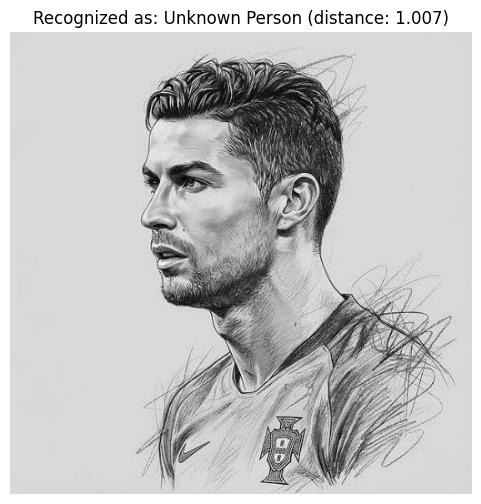


Result: Unknown Person


In [23]:
from google.colab import files
import matplotlib.pyplot as plt

print("Test karne ke liye ek naya image upload karo:")
test_uploaded = files.upload()
test_filename = list(test_uploaded.keys())[0]

name, distance = recognize_face(test_filename, known_embeddings, mtcnn, resnet, device)

img = Image.open(test_filename)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Recognized as: {name}" + (f" (distance: {distance:.3f})" if distance else ""))
plt.axis('off')
plt.show()

print(f"\nResult: {name}")

Apni koi doosri photo upload karo (test ke liye):


Saving 3a16a5dac42f2404617e47ac1bd0dd84.jpg to 3a16a5dac42f2404617e47ac1bd0dd84.jpg


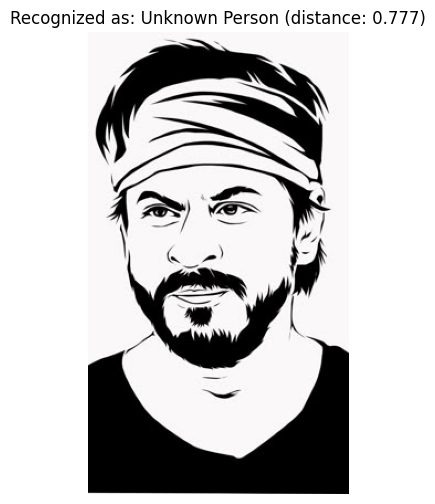


Result: Unknown Person


In [25]:
from google.colab import files
import matplotlib.pyplot as plt

print("Apni koi doosri photo upload karo (test ke liye):")
test_uploaded = files.upload()
test_filename = list(test_uploaded.keys())[0]

name, distance = recognize_face(test_filename, known_embeddings, mtcnn, resnet, device)

img = Image.open(test_filename)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Recognized as: {name}" + (f" (distance: {distance:.3f})" if distance else ""))
plt.axis('off')
plt.show()

print(f"\nResult: {name}")


In [26]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='webcam_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Photo';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print("Function ready! Ab webcam se photo le sakte ho.")

Function ready! Ab webcam se photo le sakte ho.


<IPython.core.display.Javascript object>

Photo saved: webcam_capture.jpg


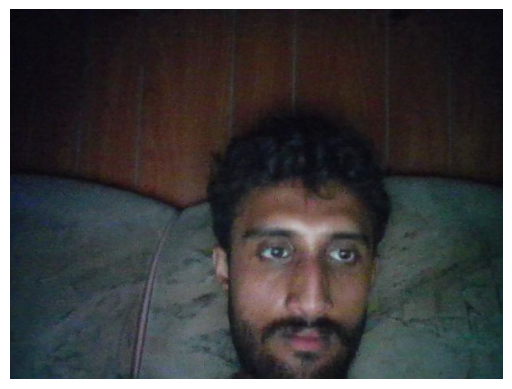

In [28]:
photo_path = take_photo()
print("Photo saved:", photo_path)

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(photo_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [29]:
import csv
from datetime import datetime
import os

attendance_file = "/content/attendance.csv"

# Agar file pehle se nahi hai to header ke sath banao
if not os.path.exists(attendance_file):
    with open(attendance_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Name", "Date", "Time"])

def mark_attendance(name):
    today = datetime.now().strftime("%Y-%m-%d")
    time_now = datetime.now().strftime("%H:%M:%S")

    # Check karo ke aaj is student ki attendance pehle se lagi hai ya nahi
    already_marked = False
    if os.path.exists(attendance_file):
        with open(attendance_file, 'r') as f:
            reader = csv.reader(f)
            next(reader, None)  # header skip karo
            for row in reader:
                if len(row) >= 2 and row[0] == name and row[1] == today:
                    already_marked = True
                    break

    if already_marked:
        print(f"⚠️ {name} ki attendance aaj pehle se lag chuki hai.")
        return False
    else:
        with open(attendance_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([name, today, time_now])
        print(f"✅ Attendance marked for {name} at {time_now}")
        return True

<IPython.core.display.Javascript object>

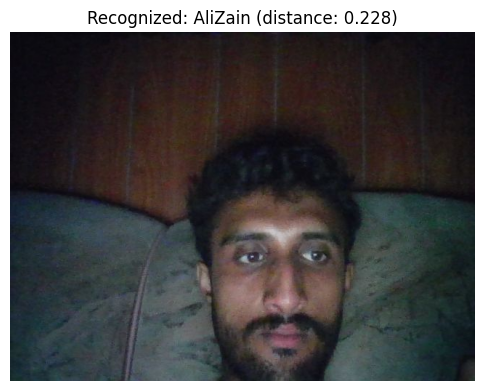

✅ Attendance marked for AliZain at 20:44:55


In [30]:
# Webcam se photo lo
photo_path = take_photo('attendance_capture.jpg')

# Face recognize karo
name, distance = recognize_face(photo_path, known_embeddings, mtcnn, resnet, device)

# Result dikhao
img = Image.open(photo_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Recognized: {name}" + (f" (distance: {distance:.3f})" if distance else ""))
plt.axis('off')
plt.show()

# Agar known person hai, attendance mark karo
if name != "Unknown Person" and name != "No face detected in image":
    mark_attendance(name)
else:
    print("❌ Attendance nahi lagi — face recognize nahi hua ya unknown person hai.")

In [32]:
import pandas as pd

df = pd.read_csv(attendance_file)
print(df)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [33]:
import csv

with open(attendance_file, 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['Name', 'Date', 'Time']
['AliZain', '2026-08-28', '20:44:55']


In [36]:
import csv

with open(attendance_file, 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['Name', 'Date', 'Time']
['AliZain', '2026-08-28', '20:44:55']


In [44]:
import os
print("Current files:", os.listdir("/content/known_faces"))

Current files: ['AliZain.jpg', 'WhatsApp Image 2026-08-28 at 1.58.58 PM.jpeg', 'Ahmed.jpg']


In [45]:
import os

os.rename("/content/known_faces/images (1).jpg", "/content/known_faces/Ahmed.jpg")

print("Renamed! Files now:", os.listdir("/content/known_faces"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/known_faces/images (1).jpg' -> '/content/known_faces/Ahmed.jpg'

In [46]:
import os

files_list = os.listdir("/content/known_faces")
print("Files:", files_list)

Files: ['AliZain.jpg', 'WhatsApp Image 2026-08-28 at 1.58.58 PM.jpeg', 'Ahmed.jpg']


In [47]:
import os

os.rename("/content/known_faces/WhatsApp Image 2026-08-28 at 1.58.58 PM.jpeg",
          "/content/known_faces/Sara.jpg")   # apna student ka naam yahan likho

print("Renamed! Files now:", os.listdir("/content/known_faces"))

Renamed! Files now: ['AliZain.jpg', 'Ahmed.jpg', 'Sara.jpg']


In [48]:
known_embeddings = {}
for filename in os.listdir("/content/known_faces"):
    person_name = os.path.splitext(filename)[0]
    filepath = os.path.join("/content/known_faces", filename)
    embedding = get_embedding(filepath, mtcnn, resnet, device)
    if embedding is not None:
        known_embeddings[person_name] = embedding
        print(f"✅ {person_name} added")

print("\nTotal students in database:", len(known_embeddings))
print("Names:", list(known_embeddings.keys()))

✅ AliZain added
✅ Ahmed added
✅ Sara added

Total students in database: 3
Names: ['AliZain', 'Ahmed', 'Sara']


In [49]:
take_attendance()

NameError: name 'take_attendance' is not defined

In [50]:
def take_attendance():
    print("📸 Camera khul raha hai... Photo lene ke liye 'Capture Photo' click karo")
    photo_path = take_photo('attendance_capture.jpg')

    name, distance = recognize_face(photo_path, known_embeddings, mtcnn, resnet, device)

    img = Image.open(photo_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Recognized: {name}")
    plt.axis('off')
    plt.show()

    if name not in ["Unknown Person", "No face detected in image"]:
        mark_attendance(name)
    else:
        print("❌ Attendance nahi lagi.")

📸 Camera khul raha hai... Photo lene ke liye 'Capture Photo' click karo


<IPython.core.display.Javascript object>

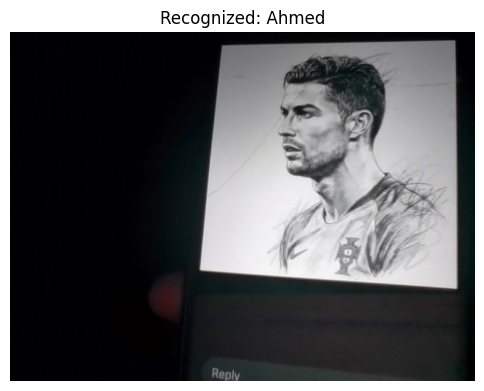

✅ Attendance marked for Ahmed at 21:11:28


In [54]:
take_attendance()

In [55]:
import csv
with open(attendance_file, 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['Name', 'Date', 'Time']
['AliZain', '2026-08-28', '20:44:55']
['Sara', '2026-08-28', '21:08:36']
['Ahmed', '2026-08-28', '21:11:28']


In [56]:
from google.colab import files
files.download('/content/attendance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
# Agar Colab mein koi capture image save karna ho reference ke liye
import shutil
os.makedirs("/content/sample_results", exist_ok=True)

# Jo bhi latest capture hui thi usko copy karo
shutil.copy("attendance_capture.jpg", "/content/sample_results/sample_recognition.jpg")

!zip -r /content/face_recognition_samples.zip /content/sample_results
files.download('/content/face_recognition_samples.zip')

  adding: content/sample_results/ (stored 0%)
  adding: content/sample_results/sample_recognition.jpg (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>